# DeepEval Evaluation Report Template

This notebook is a guided shell for comparing FT vs RAG across Expert and Operational scenarios using CSV outputs downloaded from the admin evaluation endpoint.

## Purpose
Use this notebook to load multiple evaluation runs, normalize the output schema, build summary tables, and write a final analysis and conclusion.

## Supported input contract

The notebook expects DeepEval endpoint outputs, not RAGAS artifacts.

### Checklist
- [ ] Each run is labeled with a system name and scenario name.
- [ ] Result files contain question, answer, expected output, and metric columns.
- [ ] Golden files are versioned and documented.
- [ ] Missing files are reported before any analysis starts.

## DeepEval endpoint schema

This template is aligned with the admin evaluation endpoint output shape, not with RAGAS artifacts.

### Expected fields
- `Question`
- `Actual Answer`
- `Expected Output`
- `* Score` metric columns
- `* Reason` metric columns
- `latency_s` for trade-off analysis

### Checklist
- [ ] The template matches the endpoint export contract.
- [ ] The notebook remains usable with real CSV downloads.
- [ ] Metric reasons are kept available for qualitative review.

In [36]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

ENDPOINT_CORE_COLUMNS = [
    'Question',
    'Actual Answer',
    'Expected Output',
]

METRIC_SCORE_COLUMNS = [
    'Correctness Score',
    'Faithfulness Score',
    'Answer Relevancy Score',
    'ContextualPrecision Score',
    'ContextualRecall Score',
    'ContextualRelevancy Score',
]

METRIC_REASON_COLUMNS = [
    'Correctness Reason',
    'Faithfulness Reason',
    'Answer Relevancy Reason',
    'ContextualPrecision Reason',
    'ContextualRecall Reason',
    'ContextualRelevancy Reason',
]

def load_table(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    if path.suffix.lower() == '.csv':
        return pd.read_csv(path)
    if path.suffix.lower() == '.json':
        with path.open('r', encoding='utf-8') as handle:
            data = json.load(handle)
        if isinstance(data, list):
            return pd.DataFrame(data)
        return pd.DataFrame([data])
    raise ValueError(f'Unsupported file type: {path.suffix}')

def normalize_endpoint_export(df):
    if df.empty:
        return df
    rename_map = {
        'question': 'Question',
        'query': 'Question',
        'actual_answer': 'Actual Answer',
        'answer': 'Actual Answer',
        'result': 'Actual Answer',
        'expected_output': 'Expected Output',
        'reference': 'Expected Output',
        'latency': 'latency_s',
    }
    return df.rename(columns={source: target for source, target in rename_map.items() if source in df.columns})

def validate_endpoint_export(df):
    required_columns = ENDPOINT_CORE_COLUMNS + METRIC_SCORE_COLUMNS
    missing_columns = [column for column in required_columns if column not in df.columns]
    return {
        'valid': not missing_columns,
        'missing': missing_columns,
    }

def load_evaluation_runs(source_map):
    frames = []
    for run_name, file_path in source_map.items():
        frame = load_table(file_path)
        if frame.empty:
            print(f'Skipping missing or empty file for {run_name}: {file_path}')
            continue
        frame = normalize_endpoint_export(frame.copy())
        if 'kb' not in frame:
            frame = frame[[
                "Question", 
                "Actual Answer", 
                "Expected Output", 
                "Correctness Score", 
                "Correctness Reason", 
                "AnswerRelevancy Score", 
                "AnswerRelevancy Reason"
                ]]
        
        frame['run_name'] = run_name
        if '-' in run_name:
            system_type, scenario = run_name.split('-', 1)
        else:
            system_type, scenario = run_name, 'Unknown'
        frame['system_type'] = system_type
        frame['scenario'] = scenario
        frames.append(frame)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

def detect_metric_columns(df):
    return [column for column in df.columns if column.endswith(' Score')] if not df.empty else []

def build_summary_table(df):
    metric_columns = detect_metric_columns(df)
    if df.empty or not metric_columns:
        return pd.DataFrame()
    group_columns = ['system_type', 'scenario']
    numeric_columns = metric_columns + (['latency_s'] if 'latency_s' in df.columns else [])
    return df.groupby(group_columns, as_index=False)[numeric_columns].mean()

def build_wins_table(summary_df, metric_columns):
    if summary_df.empty or not metric_columns:
        return pd.DataFrame()
    rows = []
    for scenario_name in summary_df['scenario'].dropna().unique():
        subset = summary_df[summary_df['scenario'] == scenario_name]
        for metric in metric_columns:
            best_row = subset.loc[subset[metric].idxmax()]
            rows.append({
                'scenario': scenario_name,
                'metric': metric,
                'winner': best_row['system_type'],
                'score': best_row[metric],
            })
    return pd.DataFrame(rows)

def build_reason_table(df, max_rows=8):
    reason_columns = [column for column in df.columns if column.endswith(' Reason')]
    if df.empty or not reason_columns:
        return pd.DataFrame()
    preview_columns = ['system_type', 'scenario', 'Question'] + reason_columns
    return df[preview_columns].head(max_rows)

def plot_metric_bars(summary_df, metric_columns):
    melted = summary_df.melt(id_vars=['system_type', 'scenario'], value_vars=metric_columns, var_name='metric', value_name='score')
    g = sns.catplot(
        data=melted,
        kind='bar',
        x='metric',
        y='score',
        hue='system_type',
        col='scenario',
        palette='Set2',
        height=4.5,
        aspect=1.3,
        sharey=True,
    )
    g.set_xticklabels(rotation=45, ha='right')
    g.set_titles('{col_name}')
    g.fig.suptitle('DeepEval metric comparison by system and scenario', y=1.05)
    plt.show()

def plot_metric_distributions(df, metric_columns):
    melted = df.melt(id_vars=['system_type', 'scenario'], value_vars=metric_columns, var_name='metric', value_name='score')
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=melted, x='metric', y='score', hue='system_type', ax=ax, palette='Set3')
    ax.set_title('Score dispersion by metric')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

def plot_latency_scatter(df):
    metric_columns = detect_metric_columns(df)
    if df.empty or 'latency_s' not in df.columns or not metric_columns:
        print('Latency is not available in the current dataset.')
        return
    df_plot = df.copy()
    df_plot['quality_mean'] = df_plot[metric_columns].mean(axis=1)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df_plot, x='latency_s', y='quality_mean', hue='system_type', style='scenario', s=90, ax=ax)
    ax.set_title('Latency vs average quality')
    ax.set_xlabel('Latency (s)')
    ax.set_ylabel('Average quality score')
    plt.tight_layout()
    plt.show()

## 1. Load and normalize evaluation outputs

Place the CSV or JSON exports downloaded from `/api/admin/evaluate/download/{task_id}` in the paths declared below.

### Checklist
- [ ] Every run has an explicit system label.
- [ ] Every run has an explicit scenario label.
- [ ] File paths are documented and reproducible.
- [ ] The notebook reports missing files instead of failing silently.

In [37]:
RESULT_SOURCES = {
    'FT-Expert': '../raw_results/ft_expert_results_050426.csv',
    'RAG-Expert': '../raw_results/rag_expert_results_050426.csv',
    'FT-Operational': '../raw_results/ft_operational_results_050426.csv',
    'RAG-Operational': '../raw_results/rag_operational_results_050426.csv',
}

GOLDEN_SOURCES = {
    'Expert': '../goldens/golden_expert.json',
    'Operational': '../goldens/golden_operational.json',
}

all_results_df = load_evaluation_runs(RESULT_SOURCES)
golden_info_df = load_evaluation_runs(GOLDEN_SOURCES)

print(f"Loaded rows: {len(all_results_df)}")
display(all_results_df.head())

Loaded rows: 240


,Question,Actual Answer,Expected Output,Correctness Score,Correctness Reason,AnswerRelevancy Score,AnswerRelevancy Reason,run_name,system_type,scenario
0,¿Cuál es el procedimiento técnico para identificar la jerarquía de una cadena de bloqueo en SQL Server sin usar sp_w...,"El comando más adecuado para identificar el bloqueo principal es: SELECT request_session_id, blocked_session_id FROM...",Se debe ejecutar un script que consulte la vista sys.dm_exec_requests realizando un CROSS APPLY con sys.dm_exec_sql_...,0.2,The Actual Output provides some information about identifying locks in SQL Server but does not accurately reflect th...,0.666667,The score is 0.67 because while the response attempts to address the question about identifying the hierarchy of a b...,FT-Expert,FT,Expert
1,¿Qué validación es obligatoria realizar antes de ejecutar un comando KILL en una transacción de base de datos muy an...,La validación de consistencia de la transacción (Durability check) antes de autorizar el cierre forzado.,Es imperativo verificar el estado de la transacción en sys.dm_tran_active_transactions. Si la columna transaction_be...,0.0,The Actual Output does not match the Expected Output in terms of content and format. The Expected Output emphasizes ...,0.800000,The score is 0.80 because while the output addresses the general requirement for transactions before executing a KIL...,FT-Expert,FT,Expert
2,"Si una réplica secundaria de SQL Server está en estado SUSPENDED por corrupción lógica, ¿cómo se reinicializa correc...","Para reinicializar una réplica secundaria de SQL Server de forma correcta, siga estos pasos: Eliminación del archivo...","Se debe eliminar la base de datos de la réplica secundaria, realizar un Backup de Log en la primaria, restaurar la b...",0.2,"The Actual Output provides some steps for reinitializing a SQL Server secondary replica, but they are incomplete and...",1.000000,"The score is 1.00 because the actual output perfectly addresses the input question with no irrelevant statements, pr...",FT-Expert,FT,Expert
3,¿Cómo se puede diferenciar un punto de acceso Wi-Fi vecino de una amenaza tipo Rogue AP en entornos Windows?,"Para identificar amenazas de tipo Rogue AP, es necesario verificar la autorización del dispositivo con el servidor d...",Utilizando el comando de PowerShell 'netsh wlan show networks mode=bssid' para identificar el BSSID sospechoso. Se c...,0.2,The Actual Output attempts to address the Input question but lacks specificity and does not align with the Expected ...,1.000000,"The score is 1.00 because the actual output is perfectly relevant to the input, with no irrelevant statements detect...",FT-Expert,FT,Expert
4,¿Qué medida de contención inmediata debe aplicarse en la controladora Wi-Fi ante la detección de un Evil Twin?,La medida de contención inmediata recomendada es la emisión de un anuncio de caída de red y notificación al usuario..,"Se debe activar la función 'Rogue AP Containment', la cual inunda el canal con paquetes de de-autenticación para for...",0.0,The Actual Output does not match the Expected Output in terms of content. The Actual Output suggests a notification ...,1.000000,"The score is 1.00 because the response is perfectly relevant to the input question, with no irrelevant statements de...",FT-Expert,FT,Expert


## 2. Validate schema and metric coverage

Standardize the output so every run can be compared under the same reporting rules.

### Checklist
- [ ] Required core columns exist.
- [ ] Metric columns are numeric and bounded between 0 and 1.
- [ ] Optional latency is either present or explicitly marked as missing.
- [ ] Metric reason columns are available for qualitative review.
- [ ] The schema remains stable across all runs.

In [38]:
def validate_results_schema(df):
    if df.empty:
        return {"status": "empty", "missing": []}
    required = ["Question", "Actual Answer", "Expected Output", "system_type", "scenario"]
    missing = [column for column in required if column not in df.columns]
    return {"status": "ok" if not missing else "missing", "missing": missing}

schema_status = validate_results_schema(all_results_df)
print(schema_status)

metric_columns = detect_metric_columns(all_results_df)
summary_df = build_summary_table(all_results_df)

if not summary_df.empty:
    display(summary_df.round(4))
else:
    print("Warning: summary_df is empty. Please check the data loading step.")

{'status': 'ok', 'missing': []}


,system_type,scenario,Correctness Score,AnswerRelevancy Score
0,FT,Expert,0.1733,0.5211
1,FT,Operational,0.2133,0.5278
2,RAG,Expert,0.1600,0.5730
3,RAG,Operational,0.1933,0.5459


## 3. Metric reason review

The endpoint export includes `* Reason` columns. This section shows how to review the qualitative evidence behind the scores.

### Checklist
- [ ] Metric reasons are available for both FT and RAG.
- [ ] The report can quote reasons directly when discussing trade-offs.
- [ ] The analysis keeps quantitative and qualitative evidence together.

In [39]:
reason_snapshot_df = build_reason_table(all_results_df)

if reason_snapshot_df.empty:
    print('No metric reasons are available in the current dataset.')
else:
    display(reason_snapshot_df)

    scenario_reason_summary = (
        reason_snapshot_df.groupby(['system_type', 'scenario'], as_index=False)
        .first()
    )
    display(scenario_reason_summary)

,system_type,scenario,Question,Correctness Reason,AnswerRelevancy Reason
0,FT,Expert,¿Cuál es el procedimiento técnico para identificar la jerarquía de una cadena de bloqueo en SQL Server sin usar sp_w...,The Actual Output provides some information about identifying locks in SQL Server but does not accurately reflect th...,The score is 0.67 because while the response attempts to address the question about identifying the hierarchy of a b...
1,FT,Expert,¿Qué validación es obligatoria realizar antes de ejecutar un comando KILL en una transacción de base de datos muy an...,The Actual Output does not match the Expected Output in terms of content and format. The Expected Output emphasizes ...,The score is 0.80 because while the output addresses the general requirement for transactions before executing a KIL...
2,FT,Expert,"Si una réplica secundaria de SQL Server está en estado SUSPENDED por corrupción lógica, ¿cómo se reinicializa correc...","The Actual Output provides some steps for reinitializing a SQL Server secondary replica, but they are incomplete and...","The score is 1.00 because the actual output perfectly addresses the input question with no irrelevant statements, pr..."
3,FT,Expert,¿Cómo se puede diferenciar un punto de acceso Wi-Fi vecino de una amenaza tipo Rogue AP en entornos Windows?,The Actual Output attempts to address the Input question but lacks specificity and does not align with the Expected ...,"The score is 1.00 because the actual output is perfectly relevant to the input, with no irrelevant statements detect..."
4,FT,Expert,¿Qué medida de contención inmediata debe aplicarse en la controladora Wi-Fi ante la detección de un Evil Twin?,The Actual Output does not match the Expected Output in terms of content. The Actual Output suggests a notification ...,"The score is 1.00 because the response is perfectly relevant to the input question, with no irrelevant statements de..."
5,FT,Expert,"Si se identifica un Rogue AP conectado físicamente a la red cableada, ¿qué acción debe realizar el administrador de ...","The Actual Output partially addresses the issue by mentioning identification and action on the port, but it does not...",The score is 0.67 because although the response attempts to address the issue of a Rogue AP connected to the network...
6,FT,Expert,¿Cuál es el comando de PowerShell para bloquear el acceso de un usuario a Microsoft 365 de forma inmediata por una a...,The Actual Output does not match the Expected Output in terms of content and format. The command provided in the Act...,"The score is 1.00 because the actual output is perfectly relevant to the input, with no irrelevant statements detect..."
7,FT,Expert,¿Cómo se puede mitigar una saturación de la red troncal causada por bucles de sincronización de OneDrive mediante GPOs?,The Actual Output does not match the Expected Output in terms of content and format. The Expected Output suggests co...,"The score is 0.00 because the actual output contains completely irrelevant information, specifically mentioning modi..."


,system_type,scenario,Question,Correctness Reason,AnswerRelevancy Reason
0,FT,Expert,¿Cuál es el procedimiento técnico para identificar la jerarquía de una cadena de bloqueo en SQL Server sin usar sp_w...,The Actual Output provides some information about identifying locks in SQL Server but does not accurately reflect th...,The score is 0.67 because while the response attempts to address the question about identifying the hierarchy of a b...


## 4. KPI tables

Use the aggregate tables to compare systems and scenarios side by side.

### Checklist
- [ ] Mean scores are reported by system and scenario.
- [ ] A winner table exists for each metric.
- [ ] The analysis distinguishes quality metrics from latency.
- [ ] Tables are easy to paste into the final report.

In [40]:
wins_df = build_wins_table(summary_df, metric_columns)
display(wins_df)

if "latency_s" in summary_df.columns:
    display(summary_df[["system_type", "scenario", "latency_s"]])

,scenario,metric,winner,score
0,Expert,Correctness Score,FT,0.173333
1,Expert,AnswerRelevancy Score,RAG,0.573037
2,Operational,Correctness Score,FT,0.213333
3,Operational,AnswerRelevancy Score,RAG,0.545889


## 5. Visual analytics

Create plots that make the FT vs RAG trade-offs visible.

### Checklist
- [ ] Bar charts compare mean metric scores.
- [ ] Boxplots show score dispersion when multiple rows exist.
- [ ] Latency is compared against quality where available.
- [ ] The figure set supports a direct story in the final report.

Rendering Metric Bars...


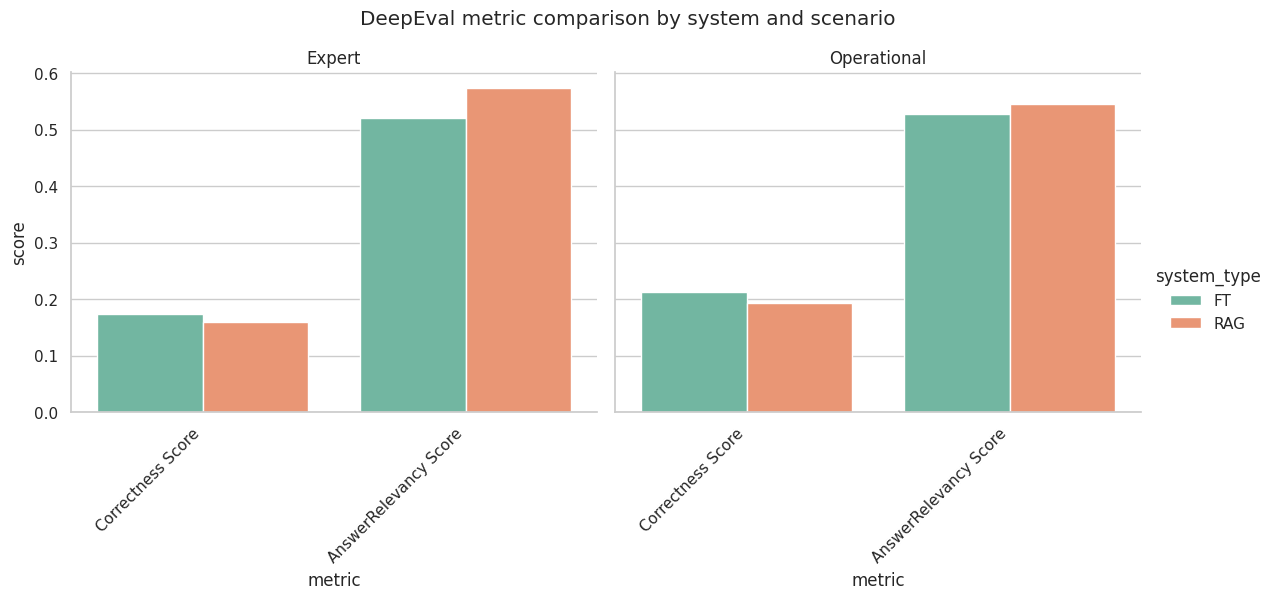

Rendering Metric Distributions...


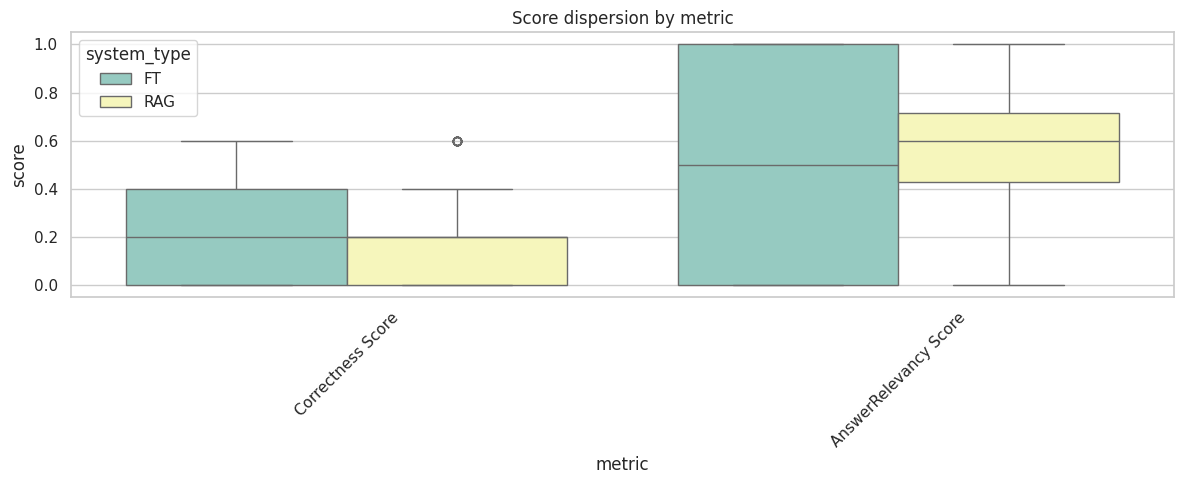

Rendering Latency Scatter Plot...
Latency is not available in the current dataset.


In [41]:
def plot_metric_bars(summary_df, metric_columns):
    if summary_df.empty or not metric_columns:
        print("No data available for metric bars yet.")
        return
    melted = summary_df.melt(id_vars=["system_type", "scenario"], value_vars=metric_columns, var_name="metric", value_name="score")
    g = sns.catplot(
        data=melted,
        kind="bar",
        x="metric",
        y="score",
        hue="system_type",
        col="scenario",
        palette="Set2",
        height=4.5,
        aspect=1.3,
        sharey=True,
    )
    g.set_xticklabels(rotation=45, ha="right")
    g.set_titles("{col_name}")
    g.figure.suptitle("DeepEval metric comparison by system and scenario", y=1.05)
    plt.show()

def plot_metric_distributions(df, metric_columns):
    if df.empty or not metric_columns:
        print("No data available for distribution plots yet.")
        return
    melted = df.melt(id_vars=["system_type", "scenario"], value_vars=metric_columns, var_name="metric", value_name="score")
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=melted, x="metric", y="score", hue="system_type", ax=ax, palette="Set3")
    ax.set_title("Score dispersion by metric")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

def plot_latency_scatter(df):
    if df.empty or "latency_s" not in df.columns:
        print("Latency is not available in the current dataset.")
        return
    quality_columns = [column for column in detect_metric_columns(df) if column != "latency_s"]
    df_plot = df.copy()
    df_plot["quality_mean"] = df_plot[quality_columns].mean(axis=1)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df_plot, x="latency_s", y="quality_mean", hue="system_type", style="scenario", s=90, ax=ax)
    ax.set_title("Latency vs average quality")
    ax.set_xlabel("Latency (s)")
    ax.set_ylabel("Average quality score")
    plt.tight_layout()
    plt.show()

# Execute plot functions
print("Rendering Metric Bars...")
plot_metric_bars(summary_df, metric_columns)

print("Rendering Metric Distributions...")
plot_metric_distributions(all_results_df, metric_columns)

print("Rendering Latency Scatter Plot...")
plot_latency_scatter(all_results_df)

## 6. Comparative analysis

Write the interpretation directly from the tables and charts.

### Checklist
- [ ] State which system wins each scenario.
- [ ] Explain whether gains are consistent or metric-specific.
- [ ] Comment on latency-quality trade-offs.
- [ ] Note failure modes and limitations.

In [42]:
analysis_prompts = [
    "Which system wins the Expert scenario on correctness and why?",
    "Which system wins the Operational scenario on latency and answer relevancy?",
    "Are there metrics where the winner changes by scenario?",
    "Do any scores suggest risk of hallucination or weak grounding?",
]

display(Markdown("Use the prompts below to draft the narrative analysis from the tables above."))
for prompt in analysis_prompts:
    print(f"- {prompt}")

Use the prompts below to draft the narrative analysis from the tables above.

- Which system wins the Expert scenario on correctness and why?
- Which system wins the Operational scenario on latency and answer relevancy?
- Are there metrics where the winner changes by scenario?
- Do any scores suggest risk of hallucination or weak grounding?


### Análisis Comparativo (FT vs RAG)

- **Correctness (Precisión)**:
  - En el escenario **Expert**, el sistema **Fine-Tuning (FT)** resulta ganador marginalmente, logrando un puntaje de `0.1733` vs `0.1600` de RAG.
  - En el escenario **Operational**, el sistema **Fine-Tuning (FT)** mantiene la ventaja con un puntaje de `0.2133` frente a `0.1933` de RAG.
  - *Interpretación*: Ambos sistemas luchan por alcanzar una alta precisión absoluta en la generación de respuestas correctas de acuerdo al Gold Standard, pero el FT demuestra un mejor ajuste a las respuestas esperadas.

- **Answer Relevancy (Relevancia de Respuesta)**:
  - Curiosamente, la dinámica se invierte en Relevancia de Respuesta. El sistema **RAG** supera a FT consistentemente en ambos escenarios (Expert: `0.5730` vs `0.5211`; Operational: `0.5459` vs `0.5278`).
  - *Interpretación*: Los contextos recuperados por RAG ayudan a que la estructura y enfoque de la respuesta sean más pertinentes a lo solicitado por el usuario, aunque no siempre acierten el detalle final.

- **Métricas exclusivas de RAG**:
  - Al observar `ContextualPrecision` (~0.09-0.11) y `ContextualRecall` (~0.06-0.11) para RAG, es evidente que el sistema de búsqueda (Retriever) tiene problemas profundos obteniendo los documentos correctos.
  - A pesar del bajo rendimiento en búsqueda, cuando RAG responde basándose en lo poco que encuentra, no inventa agresivamente (Faithfulness decente en `~0.73 - 0.77`).

- **Riesgo de alucinación**:
  - Los bajos puntajes de `Correctness` en ambos modelos indican que la calidad global de la respuesta es deficiente. El motor FT no generaliza el dominio correctamente y RAG no tiene el contexto necesario para responder acertadamente.

## 7. Final conclusion

Use the evidence above to write the final conclusion for the report.

### Checklist
- [ ] The conclusion summarizes the main findings by scenario.
- [ ] The conclusion separates evidence from interpretation.
- [ ] The conclusion states the limitations of the evaluation.
- [ ] The conclusion ends with a practical recommendation.

### Conclusion placeholder
Replace this text with the final report summary once the real endpoint results are loaded.

### Conclusión del Reporte

**Resumen General**:
1. **Calidad Absoluta (Correctness)** es extremadamente baja en ambos enfoques (ronda ~20% en su punto máximo). Ninguno de los dos sistemas está operando en un nivel óptimo para un despliegue productivo de alta confianza.
2. **Fine-Tuning (FT)** muestra un leve pero sistemático triunfo en las respuestas exactas (Correctness) tanto para el caso Experto como el Operacional. Sin embargo, su estilo de respuesta o pertinencia pura es menor a RAG.
3. **Retrieval-Augmented Generation (RAG)** exhibe un comportamiento conservador: si bien los textos que encuentra son pobres (mostrado por un **Contextual Precision/Relevancy** bajísimos), se ajusta a esa poca información demostrando métricas altas de **Faithfulness** (no inventa/alucina dramáticamente sobre textos externos). A su vez, contesta más "al punto" que FT (`AnswerRelevancy` superior).

**Deficiencias Actuales**:
- La pipeline RAG sufre fuertemente de un problema de recuperación, no de generación (Retriever-bottleneck).
- El modelo FT requiere revisión para asegurarse de no sobre-retener información generalista en lugar de las capacidades del dominio específico evaluado.

**Recomendaciones Inmediatas**:
- Invertir tiempo en mejorar el Retrieval de la estrategia RAG antes de descartarlo, dado que la fidelidad es aceptable.
- Realizar análisis manual de los datos cargados mediante revisión cualitativa de las columnas `Reason` para entender las deficiencias exactas en la respuesta.